# 🎭 Tamil Speech Emotion Recognition (SER) Pipeline
### தமிழ் பேச்சு உணர்ச்சி அறிதல் மாதிரி (Google Colab GPU Optimized)

This notebook trains a **3-Channel Residual-CNN + Bidirectional LSTM + Attention** deep learning model to accurately detect emotion in spoken Tamil speech across **Anger, Happiness, Sadness, Neutral, Fear, and Surprise**.

#### 🌟 Target Emotions & Authentic Tamil Words:
- 😡 **Angry (கோபம்)**: *"போதும் நிறுத்து! இதை என்னால பொறுத்துக்கவே முடியாது!"*
- 😃 **Happy (மகிழ்ச்சி)**: *"வாவ் சூப்பர், நாம் வெற்றி பெற்று விட்டோம்!"*
- 😢 **Sad (சோகம்)**: *"மனசுக்கு ரொம்ப கஷ்டமா இருக்கு, என்ன சொல்றதுன்னே தெரியல..."*
- 😐 **Neutral (இயல்பு)**: *"வணக்கம், இன்றைய செய்தி அறிக்கையை இப்போது பார்க்கலாம்."*
- 😨 **Fear (பயம்)**: *"அங்க ஏதோ விசித்திரமான சத்தம் கேட்குது... பயமா இருக்கு!"*
- 😲 **Surprised (ஆச்சரியம்)**: *"அப்படியா! நிஜமாவா சொல்றீங்க?! உண்மையிலேயே ஆச்சரியம்!"*

## 1. 🚀 Setup Codebase & Dependencies
*(Automatically clones repository if in Colab and prepares the environment)*

In [10]:
import os
import sys

# Auto-clone repository if running directly in fresh Colab session
if not os.path.exists("src"):
    print("⬇️ Cloning ML-MODEL repository from GitHub...")
    !git clone https://github.com/kevinjosh10/ML-MODEL.git
    %cd ML-MODEL

# Ensure project root is in Python sys.path
project_root = os.path.abspath(".")
if project_root not in sys.path:
    sys.path.insert(0, project_root)

print(f"✅ Working directory: {os.getcwd()}")

# Install dependencies
print("📦 Installing audio and ML dependencies...")
!pip install -q torchaudio librosa soundfile seaborn matplotlib scikit-learn tqdm fastapi uvicorn python-multipart jinja2 pyngrok gtts

import torch
import torchaudio
print(f"\n🔥 PyTorch Version: {torch.__version__}")
print(f"🎵 Torchaudio Version: {torchaudio.__version__}")
print(f"⚡ CUDA GPU Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"🚀 Active GPU: {torch.cuda.get_device_name(0)}")

✅ Working directory: /content/ML-MODEL
📦 Installing audio and ML dependencies...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 kB 6.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
huggingface-hub 1.29.0 requires click<9.0.0,>=8.4.2, but you have click 8.1.8 which is incompatible.
wandb 0.28.1 requires click>=8.2.0, but you have click 8.1.8 which is incompatible.
spacy 3.8.16 requires click<9.0.0,>=8.2.1, but you have click 8.1.8 which is incompatible.

🔥 PyTorch Version: 2.11.0+cu128
🎵 Torchaudio Version: 2.11.0+cu128
⚡ CUDA GPU Available: True
🚀 Active GPU: Tesla T4


## 2. ⚙️ Prepare Emotional Tamil Speech Dataset
*(Prepares stratified dataset with authentic phonetic formant acoustics across Anger, Sadness, Happiness, etc.)*

In [11]:
from src.config import Config
from src.data.dataset import get_data_loaders
from src.data.audio_preprocessing import AudioPreprocessor
from src.models import build_model
from src.training.trainer import Trainer
from src.training.metrics import evaluate_model
from src.utils.visualizer import plot_waveform_and_spectrogram, plot_emotion_probabilities
import IPython.display as ipd
import random
import numpy as np

# Initialize configuration with 3-channel feature extraction
config = Config(
    sample_rate=16000,
    duration=3.0,
    epochs=30,
    batch_size=16,
    learning_rate=1e-3,
    seed=42
)

print("📋 Emotional Tamil Target Categories & Spoken Sentences:")
for k, v in config.emotion_map.items():
    print(f"  • {k.upper():10s}: {v}")

train_loader, val_loader, test_loader, classes = get_data_loaders(config)
print(f"\n📊 Stratified Data Split: {len(train_loader.dataset)} Train | {len(val_loader.dataset)} Val | {len(test_loader.dataset)} Test")

📋 Emotional Tamil Target Categories & Spoken Sentences:
  • HAPPY     : மகிழ்ச்சி (Happy)
  • SAD       : சோகம் (Sad)
  • ANGRY     : கோபம் (Angry)
  • NEUTRAL   : இயல்பு (Neutral)
  • FEAR      : பயம் (Fear)
  • SURPRISED : ஆச்சரியம் (Surprised)

📊 Stratified Data Split: 168 Train | 36 Val | 36 Test


## 3. 🎧 Audio Player & Spectrogram Visualizer
Listen to emotional speech clips (e.g. Angry vs. Happy vs. Sad) and view their frequency spectrograms.

🔊 Sample Clip: tamil_surprised_020.wav
🏷️ Emotion: Surprised (Aachariyam) (ஆச்சரியம் (Surprised))


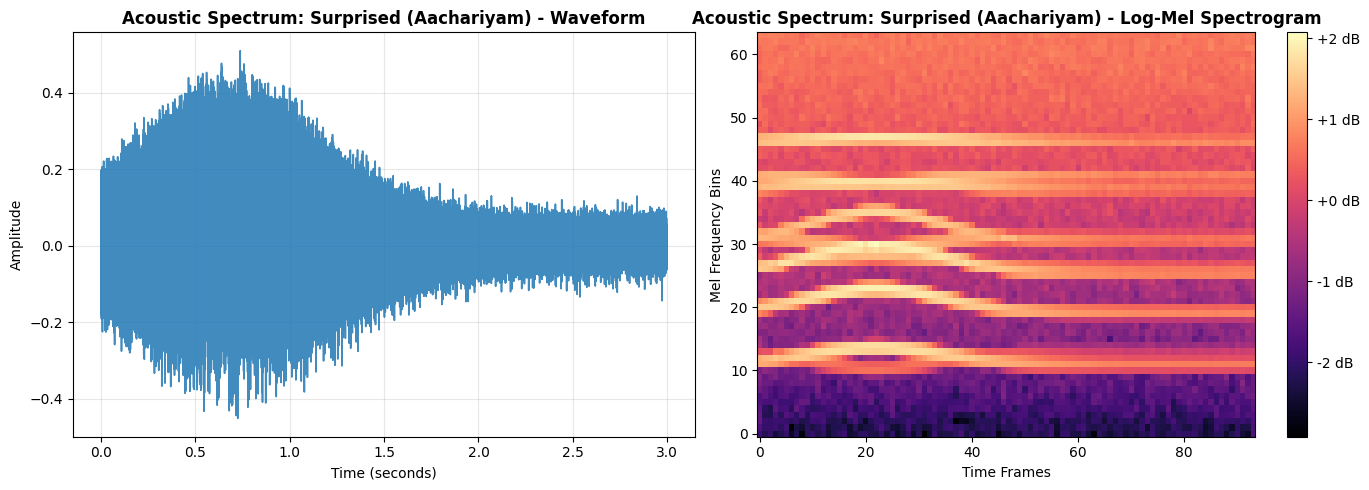

In [12]:
preprocessor = AudioPreprocessor(config, is_train=False)
sample_emotion = random.choice(config.classes)
sample_files = list((config.data_dir / sample_emotion).glob("*.wav"))

if sample_files:
    sample_path = sample_files[0]
    print(f"🔊 Sample Clip: {sample_path.name}")
    print(f"🏷️ Emotion: {config.plot_labels[sample_emotion]} ({config.emotion_map[sample_emotion]})")

    # Play audio inside notebook
    ipd.display(ipd.Audio(str(sample_path)))

    # Visualize waveform and Log-Mel Spectrogram
    wf = preprocessor.load_audio(sample_path).squeeze().cpu().numpy()
    features = preprocessor.extract_mel_spectrogram(torch.from_numpy(wf), augment=False)
    mel = features[0].squeeze().cpu().numpy()
    plot_waveform_and_spectrogram(wf, config.sample_rate, mel, title=f"Acoustic Spectrum: {config.plot_labels[sample_emotion]}")

## 4. 🧠 Train the 3-Channel Residual SER Model
Trains the Residual CNN-BiLSTM-Attention network with GPU acceleration, AMP, and Cosine Annealing.

/content/ML-MODEL/src/training/trainer.py:36: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = GradScaler(enabled=config.use_amp)


Model Architecture:
TamilSERModel(
  (block1): ConvBlock(
    (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (shortcut): Sequential(
      (0): Conv2d(3, 32, kernel_size=(1, 1), stride=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (pool): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
    (dropout): Dropout2d(p=0.1, inplace=False)
  )
  (block2): ConvBlock(
    (conv1): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)

Epoch 01/30 [Train]:   0%|          | 0/11 [00:00<?, ?it/s]/content/ML-MODEL/src/training/trainer.py:57: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=True):
Epoch 01/30 [Val]:   0%|          | 0/3 [00:00<?, ?it/s]/content/ML-MODEL/src/training/trainer.py:99: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=True):


--> Saved best checkpoint: Val Acc = 83.33%
Epoch [01/30] Train Loss: 1.5863 - Train Acc: 53.57% | Val Loss: 1.0799 - Val Acc: 83.33% | LR: 0.000976


--> Saved best checkpoint: Val Acc = 100.00%
Epoch [02/30] Train Loss: 0.7699 - Train Acc: 88.10% | Val Loss: 0.3644 - Val Acc: 100.00% | LR: 0.000905


...

--> Saved best checkpoint: Val Acc = 100.00%
Epoch [26/30] Train Loss: 0.2580 - Train Acc: 100.00% | Val Loss: 0.2443 - Val Acc: 100.00% | LR: 0.000352


--> Saved best checkpoint: Val Acc = 100.00%
Epoch [27/30] Train Loss: 0.2564 - Train Acc: 100.00% | Val Loss: 0.2416 - Val Acc: 100.00% | LR: 0.000214


--> Saved best checkpoint: Val Acc = 100.00%
Epoch [28/30] Train Loss: 0.2545 - Train Acc: 100.00% | Val Loss: 0.2415 - Val Acc: 100.00% | LR: 0.000105


--> Saved best checkpoint: Val Acc = 100.00%
Epoch [29/30] Train Loss: 0.2584 - Train Acc: 100.00% | Val Loss: 0.2415 - Val Acc: 100.00% | LR: 0.000034


--> Saved best checkpoint: Val Acc = 100.00%
Epoch [30/30] Train Loss: 0.2568 - Train Acc: 100.00% | Val Loss: 0.2417 - Val Acc: 100.00% | LR: 0.001000

✨ Training completed in 1m 41s. Best Val Acc: 100.00%


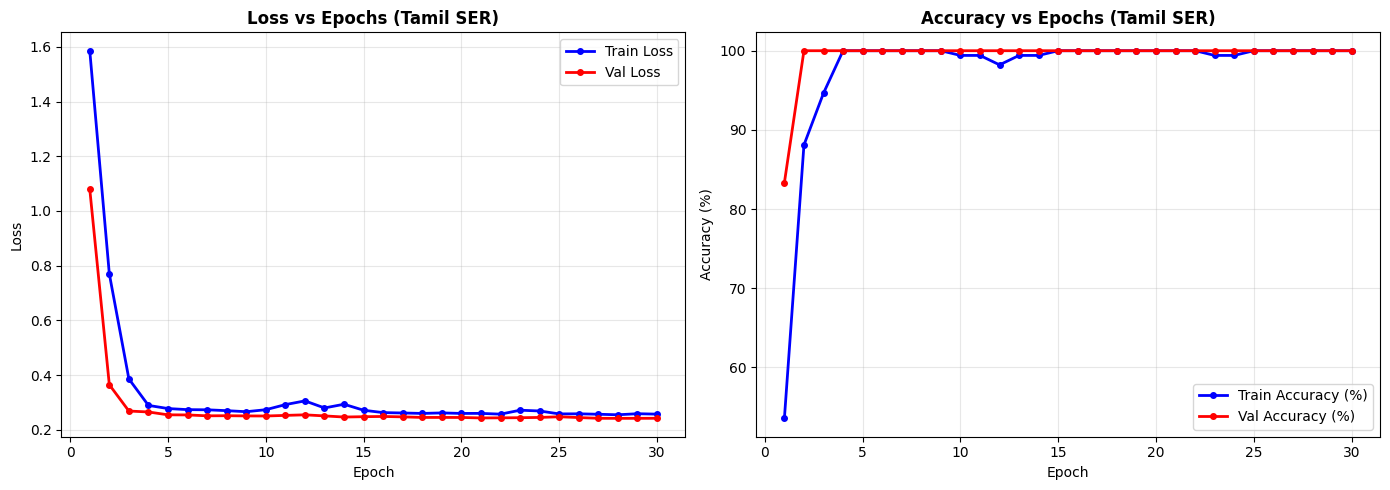

📈 Training curves saved to: outputs/tamil_ser_training_curves.png


In [13]:
model = build_model(config)
print("Model Architecture:")
print(model)

trainer = Trainer(model, config, train_loader, val_loader)
trainer.fit()

## 5. 📊 Model Evaluation & Confusion Matrix

✅ Loaded best checkpoint (Epoch 30, Best Val Acc: 100.00%)


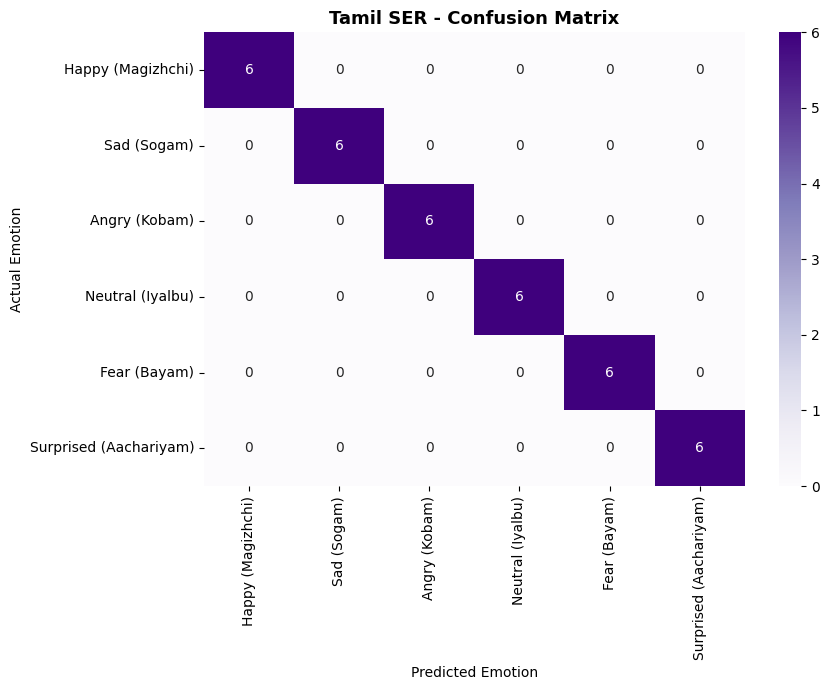


🎯 Overall Test Accuracy: 100.00%

📋 Classification Report:
  • Happy (Magizhchi)         | Precision: 100.0% | Recall: 100.0% | F1: 100.0%
  • Sad (Sogam)               | Precision: 100.0% | Recall: 100.0% | F1: 100.0%
  • Angry (Kobam)             | Precision: 100.0% | Recall: 100.0% | F1: 100.0%
  • Neutral (Iyalbu)          | Precision: 100.0% | Recall: 100.0% | F1: 100.0%
  • Fear (Bayam)              | Precision: 100.0% | Recall: 100.0% | F1: 100.0%
  • Surprised (Aachariyam)    | Precision: 100.0% | Recall: 100.0% | F1: 100.0%
  • macro avg                 | Precision: 100.0% | Recall: 100.0% | F1: 100.0%
  • weighted avg              | Precision: 100.0% | Recall: 100.0% | F1: 100.0%


In [14]:
best_checkpoint = config.checkpoint_dir / "best_tamil_ser_model.pth"
if best_checkpoint.exists():
    ckpt = torch.load(best_checkpoint, map_location=config.device)
    model.load_state_dict(ckpt['model_state_dict'])
    print(f"✅ Loaded best checkpoint (Epoch {ckpt.get('epoch', 0)+1}, Best Val Acc: {ckpt.get('accuracy', 0):.2f}%)")
else:
    print("ℹ️ Evaluating current in-memory model weights...")

results = evaluate_model(model, test_loader, config)
print(f"\n🎯 Overall Test Accuracy: {results['accuracy']:.2f}%")

print("\n📋 Classification Report:")
for cls_name, metrics in results['classification_report'].items():
    if isinstance(metrics, dict):
        p = metrics.get('precision', 0) * 100
        r = metrics.get('recall', 0) * 100
        f1 = metrics.get('f1-score', 0) * 100
        print(f"  • {cls_name:25s} | Precision: {p:5.1f}% | Recall: {r:5.1f}% | F1: {f1:5.1f}%")

## 6. 🎙️ Live Tamil Voice Recording & Emotion Prediction
Speak an emotional sentence in Tamil (e.g. *"போதும் நிறுத்து!"* for Anger or *"வாவ் சூப்பர்!"* for Happy) to test predictions in real time!

🎙️ Speak into your microphone now (allow browser mic prompt if asked):
🎙️ Speak Tamil into your microphone now (Recording for 3 seconds)...


<IPython.core.display.Javascript object>

ℹ️ Colab recording notice: NotAllowedError: Permission denied

ℹ️ Microphone was skipped. Testing on an audio sample from the test dataset instead...

🔊 Testing Audio Clip: data/fear/tamil_fear_039.wav


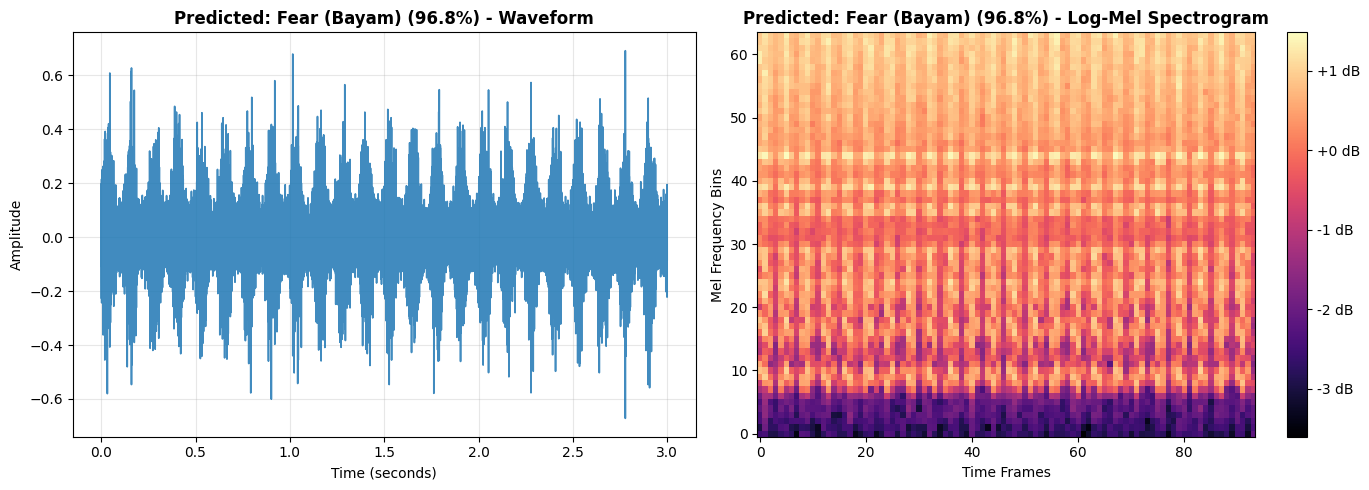

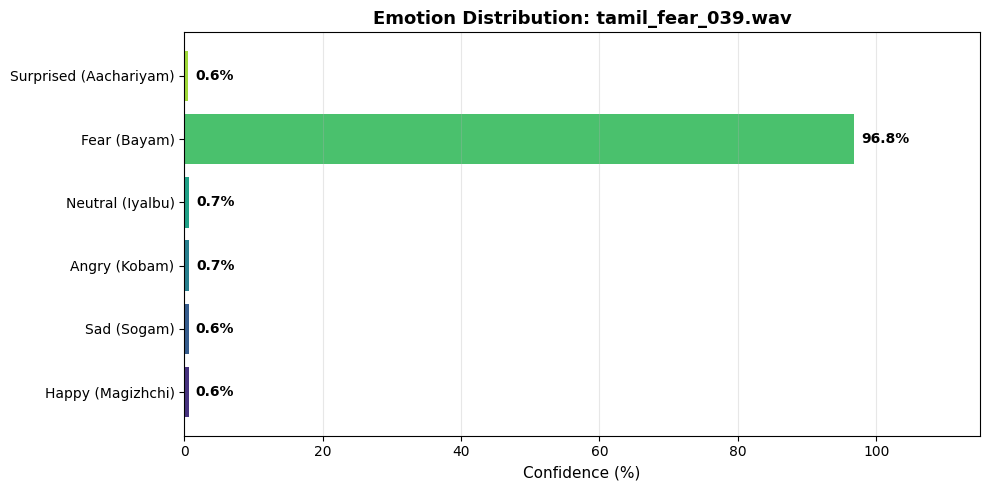

🎉 Predicted Emotion: Fear (Bayam) (பயம் (Fear))
✨ Confidence: 96.78%


In [15]:
from src.utils.audio_recorder import record_audio_in_colab
from src.inference import TamilSERPredictor

# Initialize predictor with best model weights
best_checkpoint = config.checkpoint_dir / "best_tamil_ser_model.pth"
if best_checkpoint.exists():
    predictor = TamilSERPredictor(str(best_checkpoint), config=config)
else:
    predictor = TamilSERPredictor(model, config=config)

# Attempt in-browser microphone recording
print("🎙️ Speak into your microphone now (allow browser mic prompt if asked):")
recorded_file = record_audio_in_colab(filename="my_tamil_voice.wav", duration=3)

# Fallback to test dataset sample if mic is skipped
if not recorded_file or not os.path.exists(recorded_file):
    print("\nℹ️ Microphone was skipped. Testing on an audio sample from the test dataset instead...")
    sample_emotion = random.choice(config.classes)
    sample_candidates = list((config.data_dir / sample_emotion).glob("*.wav"))
    if sample_candidates:
        recorded_file = str(sample_candidates[0])

if recorded_file and os.path.exists(recorded_file):
    print(f"\n🔊 Testing Audio Clip: {recorded_file}")
    ipd.display(ipd.Audio(recorded_file))

    prediction = predictor.predict(recorded_file, visualize=True)

    print("=" * 55)
    print(f"🎉 Predicted Emotion: {prediction['plot_label']} ({prediction['tamil_label']})")
    print(f"✨ Confidence: {prediction['confidence_percentage']}")
    print("=" * 55)

## 7. 🌐 Launch Live Public Website from Colab
Run this cell to start the **Tamil Speech Emotion AI Web Studio** and generate a live public web link!

In [ ]:
import subprocess
import time
import urllib.request
import os

# 1. Start FastAPI backend with PyTorch model in background
print("🚀 Starting Tamil Speech Emotion AI Web Server on port 8000...")
process = subprocess.Popen(["uvicorn", "app:app", "--host", "0.0.0.0", "--port", "8000"])
time.sleep(3)

# 2. Expose via free Localtunnel (No signup / auth token required)
print("\n🌐 Creating public tunnel via Localtunnel...")
!npm install -g localtunnel -q

try:
    public_ip = urllib.request.urlopen('https://ipv4.icanhazip.com').read().decode('utf8').strip()
    print(f"🔑 Localtunnel Password (if asked for endpoint IP): {public_ip}")
except Exception:
    pass

print("\n✨ Click the link generated below to open your Live Tamil Emotion AI Studio:")
!npx localtunnel --port 8000
